# E16 — Document Parsing Became a VLM Problem

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- See what a PDF actually stores, and why "extract the text" is not one operation but several with different losses
- Score a regex-and-whitespace extraction pipeline against a **checked-in reference parse** at the level of individual table cells
- Separate two things students routinely conflate: **character survival** (are the letters there?) and **structure recovery** (is this value in the right row and column?)
- Run the experiment that explains the last five years of document AI: change the *extraction mode*, not the parser, and watch accuracy move from 0% to 100%
- State precisely what a document-parsing vision-language model contributes, and why this notebook cannot run one

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 1, lesson 01 `examples/01_text_preprocessing.ipynb`. That lesson takes a
string and cleans it: lowercasing, punctuation, whitespace, a `re`-based pipeline. It is correct and it is
where every NLP course starts. This notebook asks the question that comes *before* it — **where did the
string come from?** — because in 2026 the answer is almost never "someone handed me a `.txt` file". It also
builds on Course 05 (AIAT 115) — Unit 2, lesson 08 `examples/08_feature_extraction_unstructured.ipynb`,
which extracts features from unstructured sources.

**Used later in:** Course 07 — Unit 2, which tokenizes the text this stage produced, and Unit 3, which turns
it into TF-IDF features. Every error made here is silently inherited by both. A table cell that landed in the
wrong column does not raise an exception; it becomes a feature.

> ### ⚠️ This lesson is deliberately half-runnable
> The heuristic extraction pipeline runs live and every number it produces is computed in this notebook.
> The **vision-language model half cannot run here**: SmolDocling is 256M parameters and MinerU2.5 is 1.2B,
> and both require downloading pretrained weights that this offline CPU budget does not allow. Part 6
> presents their **published claims as a clearly labelled read-only comparison**. No model is run at any
> point, and the checked-in artifacts in `assets/` say so in their own headers.

## 🌍 Why this matters: the input to your NLP pipeline is a scan of a fax

Every NLP course teaches on clean text. Every NLP job starts with a folder of PDFs — contracts, invoices,
lab reports, government forms, scanned and re-scanned — and the first six weeks are spent getting text out of
them. That extraction step used to be a pipeline of specialised parts: an OCR engine, a layout detector, a
table-structure model, a reading-order heuristic, and a large pile of regular expressions holding it together.

Two 2025 papers show what replaced it. Nassar et al. introduced **SmolDocling**, "an ultra-compact
vision-language model targeting end-to-end document conversion", which "processes entire pages by generating
DocTags, a new universal markup format that captures all page elements in their full context with location"
— in **256 million parameters**, and they report it "competes with other Vision Language Models that are up to
27 times larger in size" ([arXiv:2503.11576](https://arxiv.org/abs/2503.11576)). Niu et al. introduced
**MinerU2.5**, a **1.2B-parameter** parser using "a coarse-to-fine, two-stage parsing strategy that decouples
global layout analysis from local content recognition": stage one finds the structure on a downsampled image,
stage two reads the content from native-resolution crops of the regions stage one found
([arXiv:2509.22186](https://arxiv.org/abs/2509.22186)).

Notice what MinerU2.5's two stages are. **Layout first, characters second.** That ordering is the whole
lesson, and you are about to measure why: in the experiment below, the characters are never the problem.

**What goes wrong without this lesson.** A team writes a regex extractor against ten sample PDFs, it works,
and it ships. Three months later the vendor changes their template, a two-column page arrives, or a scan
comes in with no text layer at all, and the pipeline does not crash — it silently produces text with the
columns interleaved. Downstream, the model trains on it. Nobody looks at the intermediate file, because it is
"just plumbing". The whole system is wrong and every component reports success.

## 📥 Inputs & 📤 Outputs

**Inputs:** all local, no downloads, no network, no randomness.

- `docs/QUICK_REFERENCE_GUIDE.md` — a **real document in this repository**: the diploma's course reference
  sheet, with two six-row tables of course codes, titles, hours, CLO counts and topics.
- `assets/page_text_layer_raw.txt` and `assets/page_text_layer_layout.txt` — two **simulated PDF text
  layers** of that page, produced by the checked-in `assets/make_text_layers.py`. They reproduce the losses a
  real extractor suffers; they are not real extractor output, and `assets/README.md` says so.
- `assets/reference_parse.md` — the **correct structured parse**: our ground truth. Written by the lesson
  author from the source document. **Not** a model output.

**Outputs:** a 12-record × 5-field ground-truth table; excerpts of both text layers; a scoring function
that reports character survival and cell-level structure recovery separately; a four-row experiment table;
a chart; and a demonstration of the classic single-space column-inference failure.

## Part 1: The Document and the Reference Parse

A PDF page contains no paragraphs, no rows and no columns. It contains **glyphs with coordinates**. Everything
else — "this is a table", "this cell belongs to that row" — is an inference someone has to make. When you call
a text extractor, you are asking a library to make those inferences for you, and different libraries make
different ones.

Start from the other end: what should the answer be? `assets/reference_parse.md` holds it.

In [1]:
# WHAT: load the checked-in reference parse (our ground truth) and cross-check it against the live
#       source document, so a change to the repo cannot silently invalidate the scores below.
# WHY:  ground truth that nobody verifies is just another file. This cell verifies it.
import re
from pathlib import Path
import pandas as pd

# WHAT: resolve every file this lesson reads by its path INSIDE the repository, and fetch it
#       over the network when there is no repository to read it from.
# WHY:  walking up from the working directory covers "opened from the repo root" and "opened from
#       this folder" alike, so no '../../..' is needed and no cwd breaks it. On Google Colab
#       there is no clone to walk up to at all, so repo_file() downloads the file instead of
#       raising: a lesson that dies at cell one costs the class its first ten minutes.
import urllib.parse
import urllib.request

GITHUB_RAW = "https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/"
ASSET_DIR = "Course 07/unit1-nlp-fundamentals/enrichment/assets"

def find_repo_root(start: Path):
    """The first parent holding the course folders. None when this is not a clone of the repo."""
    for parent in [start, *start.parents]:
        if (parent / "Course 01").is_dir() and (parent / "Course 12").is_dir():
            return parent
    return None

REPO = find_repo_root(Path.cwd())
DOWNLOADS = Path.cwd() / "_repo_files"          # only ever used when there is no repository

def repo_file(rel: str) -> Path:
    """A readable local Path for a file named by its path inside the repository."""
    if REPO is not None:
        return REPO / rel
    local = DOWNLOADS / rel
    if not local.exists():
        local.parent.mkdir(parents=True, exist_ok=True)
        url = GITHUB_RAW + urllib.parse.quote(rel)      # 'Course 07' has a space in it
        try:
            urllib.request.urlretrieve(url, local)
        except Exception as exc:
            raise RuntimeError(
                f"No AI Diploma repository above {Path.cwd()}, and '{rel}' could not be "
                f"downloaded from {url}. Reconnect to the internet and re-run this cell, or open "
                f"this notebook inside a clone of "
                f"https://github.com/A-Alwabel/AI-Diploma-Program  (underlying error: {exc})"
            ) from None
    return local

print("files below read from:",
      "your clone of the repository" if REPO is not None
      else "GitHub (no clone found - Colab, or a stray copy of this notebook)")

def parse_markdown_tables(lines):
    """Pull every markdown table out of a list of lines as {heading, header, rows}."""
    tables, current, heading = [], None, None
    for line in lines:
        if line.startswith("### "):
            heading = line[4:].strip()
        if line.strip().startswith("|"):
            row = [c.strip() for c in line.strip().strip("|").split("|")]
            if all(set(c) <= set("-: ") for c in row):
                continue                                       # the |---|---| separator row
            row = [re.sub(r"\*\*(.*?)\*\*", r"\1", c) for c in row]      # strip bold markers
            if current is None:
                current = {"heading": heading, "header": row, "rows": []}
            else:
                current["rows"].append(row)
        elif current is not None:
            tables.append(current); current = None
    if current is not None:
        tables.append(current)
    return tables

# Ground truth: the checked-in reference parse.
reference_md = repo_file(f"{ASSET_DIR}/reference_parse.md").read_text(encoding="utf-8")
reference_tables = parse_markdown_tables(reference_md.split("\n"))
GROUND_TRUTH = [row for t in reference_tables for row in t["rows"]]
FIELDS = reference_tables[0]["header"]

# Integrity check: does it still agree with the live source document?
source_lines = repo_file("docs/QUICK_REFERENCE_GUIDE.md").read_text(encoding="utf-8").split("\n")[:29]
source_rows = [row for t in parse_markdown_tables(source_lines) for row in t["rows"]]
agrees = source_rows == GROUND_TRUTH

print(f"reference parse : {ASSET_DIR}/reference_parse.md")
print(f"fields          : {FIELDS}")
print(f"records         : {len(GROUND_TRUTH)}   cells: {len(GROUND_TRUTH) * len(FIELDS)}")
print(f"agrees with docs/QUICK_REFERENCE_GUIDE.md : {agrees}")
if not agrees:
    print("  !! the source document changed; re-run assets/make_text_layers.py and regenerate the parse")

print("\nFirst three ground-truth records:")
print(pd.DataFrame(GROUND_TRUTH[:3], columns=FIELDS).to_string(index=False))

files below read from: your clone of the repository
reference parse : Course 07/unit1-nlp-fundamentals/enrichment/assets/reference_parse.md
fields          : ['Code', 'Course', 'Hours', 'CLOs', 'Key Topics']
records         : 12   cells: 60
agrees with docs/QUICK_REFERENCE_GUIDE.md : True

First three ground-truth records:
    Code                                                   Course Hours CLOs                                                                  Key Topics
AIAT 111 Introduction to Artificial Intelligence and Applications    64    8         AI history, search algorithms, neural networks, generative AI intro
AIAT 112                       Python for Artificial Intelligence    96    5   Python programming, AI algorithms, knowledge representation, optimization
AIAT 113         Mathematics and Probability for Machine Learning    64    6 Linear algebra, calculus, probability, statistics, dimensionality reduction


## Part 2: Two Text Layers, Two Different Losses

Ask three PDF libraries for "the text" of the same page and you get three different files. The two extremes
are worth knowing by name, because they are what `pdftotext` gives you with and without one flag:

- **Storage order** (`pdftotext`, default). The glyph runs come out in the order the file stores them, joined
  by spaces. Every character survives. **All geometry is gone** — there is no way to tell a column break from
  a word space.
- **Layout preserving** (`pdftotext -layout`). The tool reconstructs approximate character columns with
  spaces. Geometry mostly survives. But each cell is wrapped **inside its own column**, so a single logical
  table row becomes two or three physical lines with nothing marking where a row starts.

Both files are in `assets/`, both were produced by the checked-in `assets/make_text_layers.py`, and both are
simulations of those documented behaviours rather than real extractor output. `assets/README.md` states that
in writing; this notebook restates it because it matters.

In [2]:
# WHAT: read the two simulated text layers and print an excerpt of each.
# WHY:  you cannot reason about an extraction failure you have not looked at. Read both excerpts
#       before reading the scores - the failure should be obvious to your eye first.
text_raw = repo_file(f"{ASSET_DIR}/page_text_layer_raw.txt").read_text(encoding="utf-8")
text_layout = repo_file(f"{ASSET_DIR}/page_text_layer_layout.txt").read_text(encoding="utf-8")

print("=" * 100)
print("STORAGE ORDER  (pdftotext default) - all characters, no geometry")
print("=" * 100)
print("\n".join(text_raw.split("\n")[:8]))

print("\n" + "=" * 100)
print("LAYOUT PRESERVING  (pdftotext -layout) - geometry kept, rows split across physical lines")
print("=" * 100)
print("\n".join(text_layout.split("\n")[:13]))

print(f"\nboth files describe the SAME page: "
      f"{len(text_raw.split()):,} whitespace tokens in storage order, "
      f"{len(text_layout.split()):,} in layout mode")

STORAGE ORDER  (pdftotext default) - all characters, no geometry
AI Diploma - Quick Reference Guide
Semester 1
Code Course Hours CLOs Key Topics AIAT 111 Introduction to Artificial
Intelligence and Applications 64 8 AI history, search algorithms, neural
networks, generative AI intro AIAT 112 Python for Artificial Intelligence 96 5
Python programming, AI algorithms, knowledge representation, optimization AIAT
113 Mathematics and Probability for Machine Learning 64 6 Linear algebra,
calculus, probability, statistics, dimensionality reduction AIAT 114 Machine

LAYOUT PRESERVING  (pdftotext -layout) - geometry kept, rows split across physical lines
AI Diploma - Quick Reference Guide

Semester 1

Code          Course                      Hours    CLOs    Key Topics

AIAT 111      Introduction to Artificial  64       8       AI history, search algorithms, neural
              Intelligence and                             networks, generative AI intro
              Applications
AIAT 112      P

## Part 3: One Parser, Two Metrics

We write **one** extraction function and give it a switch. That is deliberate: the experiment in Part 4 must
change exactly one thing, and if we wrote a different parser per mode we would be comparing programmers, not
extraction modes.

- **Naive mode** — the pipeline nearly every team writes first: split each line on runs of two or more
  spaces, keep the lines that produce enough fields, call them records.
- **Geometry mode** — the classic layout-aware upgrade: find the character positions that are blank on
  *every* line of the block (those are the column gaps), slice each line at those positions, and fold
  continuation lines into the record above.

And we score with **two** metrics, because they answer different questions:

| metric | question it answers | why it matters |
|---|---|---|
| **character survival** | after collapsing whitespace, does each ground-truth cell string appear verbatim anywhere in the file? | tells you whether the *characters* were lost |
| **cell recovery** | is each cell in the right record and the right field? | tells you whether the *structure* was lost |

Almost everyone measures the first and reports it as if it were the second.

In [3]:
# WHAT: the extraction pipeline. One function, one switch, plus the two scoring functions.
# WHY:  this is the artifact worth taking away. Point it at your own extractor output and it will
#       tell you, per cell, what your pipeline is actually losing.
RUNNING_HEADER = "AI Diploma - Quick Reference Guide"

def content_blocks(text):
    """Split the page into blocks at the running header, and drop headers, footers and captions."""
    blocks = []
    for chunk in [c for c in text.split(RUNNING_HEADER) if c.strip()]:
        lines = []
        for line in chunk.split("\n"):
            stripped = line.strip()
            if not stripped:
                continue
            if stripped.startswith("AI Diploma") and "page" in stripped:
                continue                                   # page footer
            if stripped in ("Semester 1", "Semester 2"):
                continue                                   # section caption
            lines.append(line)
        if lines:
            blocks.append(lines)
    return blocks

def infer_column_starts(lines, min_gap=2):
    """Column starts = the first character after every run of >= min_gap columns blank in EVERY line."""
    width = max(len(line) for line in lines)
    padded = [line.ljust(width) for line in lines]
    blank = [all(p[i] == " " for p in padded) for i in range(width)]
    starts, i = ([0] if not blank[0] else []), 0
    while i < width:
        if blank[i]:
            j = i
            while j < width and blank[j]:
                j += 1
            if j - i >= min_gap and j < width:
                starts.append(j)
            i = j
        else:
            i += 1
    return starts

def extract_records(text, use_geometry, min_gap=2):
    """Recover (record, field) structure from a text layer. One switch: use_geometry."""
    records = []
    for lines in content_blocks(text):
        if use_geometry:
            starts = infer_column_starts(lines, min_gap)
            if len(starts) < 2:
                continue                                   # no columns found: nothing to slice on
            for line in lines:
                cells = [line[a:b].strip() for a, b in zip(starts, starts[1:] + [10 ** 6])]
                if cells[0]:
                    records.append(cells)                  # a new record starts in the first column
                elif records:                              # continuation line: fold it into the last record
                    for j, cell in enumerate(cells):
                        if cell:
                            records[-1][j] = (records[-1][j] + " " + cell).strip()
        else:
            for line in lines:
                fields = re.split(r"\s{2,}", line.strip())
                if len(fields) >= 4:
                    records.append(fields)
    return [r for r in records if r and r[0] != FIELDS[0]]   # drop the repeated column-header row

def character_survival(text):
    """How many ground-truth cell strings survive verbatim once whitespace is collapsed?"""
    flat = re.sub(r"\s+", " ", text)
    return sum(1 for row in GROUND_TRUTH for cell in row if cell in flat)

def cell_recovery(records):
    """How many cells are in the right record AND the right field?"""
    correct = 0
    for i, truth in enumerate(GROUND_TRUTH):
        got = records[i] if i < len(records) else []
        for j, cell in enumerate(truth):
            if j < len(got) and got[j] == cell:
                correct += 1
    return correct

TOTAL_CELLS = len(GROUND_TRUTH) * len(FIELDS)
print(f"scoring against {len(GROUND_TRUTH)} records x {len(FIELDS)} fields = {TOTAL_CELLS} cells")
demo = extract_records(text_layout, use_geometry=False)
print(f"\nnaive parser on the layout text layer found {len(demo)} records; the first one is:")
for field, value in zip(FIELDS, demo[0]):
    print(f"   {field:<12s} {value!r}")

scoring against 12 records x 5 fields = 60 cells

naive parser on the layout text layer found 12 records; the first one is:
   Code         'AIAT 111'
   Course       'Introduction to Artificial'
   Hours        '64'
   CLOs         '8'
   Key Topics   'AI history, search algorithms, neural'


## Part 4: The Experiment — Change the Extraction Mode, Not the Parser

**Baseline.** Storage-order text layer, naive parser. This is the honest description of a very large number
of production pipelines.

**Change one thing.** The extraction mode: hand the *same* parser the layout-preserving text layer instead.

**Change one more thing.** Turn on geometry inference, still on the same document, same ground truth, same
scoring.

Nothing about the document, the ground truth or the metric moves. Read the two columns against each other.

In [4]:
# WHAT: run all four combinations of (extraction mode) x (parser mode) and score both metrics.
# WHY:  the two metrics move in opposite directions across the first two rows, and that opposition
#       is the entire point of the lesson.
experiments = [
    ("storage order", "naive",    text_raw,    False),
    ("storage order", "geometry", text_raw,    True),
    ("layout mode",   "naive",    text_layout, False),
    ("layout mode",   "geometry", text_layout, True),
]

results = []
for extraction, parser, text, geometry in experiments:
    records = extract_records(text, use_geometry=geometry)
    survived = character_survival(text)
    recovered = cell_recovery(records)
    results.append({
        "extraction mode": extraction,
        "parser": parser,
        "records found": len(records),
        "character survival": survived / TOTAL_CELLS,
        "cell recovery": recovered / TOTAL_CELLS,
    })

table = pd.DataFrame(results)
print(table.to_string(index=False, formatters={
    "character survival": "{:.0%}".format, "cell recovery": "{:.0%}".format}))

base = table.iloc[0]
mid = table.iloc[2]
best = table.iloc[3]
print(f"\nCONCLUSION SUPPORTED BY THESE NUMBERS:")
print(f"  Baseline (storage order + naive parser): {base['character survival']:.0%} of the characters are")
print(f"  present and {base['cell recovery']:.0%} of the cells are recoverable. Every letter of the table")
print(f"  survived the extraction and not one value can be tied to a row and a column.")
print(f"  Switch the extraction mode only  -> cell recovery {base['cell recovery']:.0%} -> {mid['cell recovery']:.0%}")
print(f"  Add geometry inference           -> cell recovery {mid['cell recovery']:.0%} -> {best['cell recovery']:.0%}")
print(f"  The parser's regexes never improved. The information did.")

extraction mode   parser  records found character survival cell recovery
  storage order    naive              0               100%            0%
  storage order geometry              0               100%            0%
    layout mode    naive             12                77%           68%
    layout mode geometry             12                77%          100%

CONCLUSION SUPPORTED BY THESE NUMBERS:
  Baseline (storage order + naive parser): 100% of the characters are
  present and 0% of the cells are recoverable. Every letter of the table
  survived the extraction and not one value can be tied to a row and a column.
  Switch the extraction mode only  -> cell recovery 0% -> 68%
  Add geometry inference           -> cell recovery 68% -> 100%
  The parser's regexes never improved. The information did.


In [5]:
# WHAT: show exactly which fields the naive parser loses on the layout text layer.
# WHY:  an aggregate score tells you there is a problem; a per-field breakdown tells you it is always
#       the same two fields, and why.
naive_records = extract_records(text_layout, use_geometry=False)
geometry_records = extract_records(text_layout, use_geometry=True)

per_field = []
for j, field in enumerate(FIELDS):
    naive_ok = sum(1 for i, truth in enumerate(GROUND_TRUTH)
                   if j < len(naive_records[i]) and naive_records[i][j] == truth[j])
    geom_ok = sum(1 for i, truth in enumerate(GROUND_TRUTH)
                  if j < len(geometry_records[i]) and geometry_records[i][j] == truth[j])
    per_field.append({"field": field, "naive": naive_ok, "geometry": geom_ok,
                      "of": len(GROUND_TRUTH)})
per_field_df = pd.DataFrame(per_field)
print(per_field_df.to_string(index=False))

print("\nThe two fields the naive parser loses are exactly the two long ones. Compare record 1:\n")
for label, rec in (("ground truth", GROUND_TRUTH[0]), ("naive      ", naive_records[0]),
                   ("geometry   ", geometry_records[0])):
    print(f"  {label}:")
    for field, value in zip(FIELDS, rec):
        print(f"      {field:<12s} {value!r}")
print("\nThe naive parser did not mangle those cells. It read the first physical line of a row that")
print("occupies three, and had no way to know the other two lines belonged to it.")

     field  naive  geometry  of
      Code     12        12  12
    Course      5        12  12
     Hours     12        12  12
      CLOs     12        12  12
Key Topics      0        12  12

The two fields the naive parser loses are exactly the two long ones. Compare record 1:

  ground truth:
      Code         'AIAT 111'
      Course       'Introduction to Artificial Intelligence and Applications'
      Hours        '64'
      CLOs         '8'
      Key Topics   'AI history, search algorithms, neural networks, generative AI intro'
  naive      :
      Code         'AIAT 111'
      Course       'Introduction to Artificial'
      Hours        '64'
      CLOs         '8'
      Key Topics   'AI history, search algorithms, neural'
  geometry   :
      Code         'AIAT 111'
      Course       'Introduction to Artificial Intelligence and Applications'
      Hours        '64'
      CLOs         '8'
      Key Topics   'AI history, search algorithms, neural networks, generative AI intro'



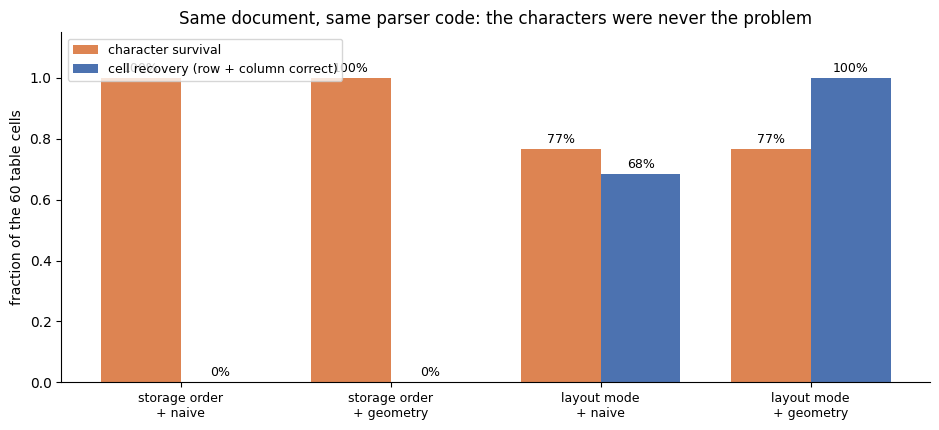

In [6]:
# WHAT: plot the two metrics side by side for the four configurations.
# WHY:  the shape of this chart - one metric flat, the other stepping from zero to one - is the
#       single image to keep from this notebook.
import matplotlib.pyplot as plt        # the notebook kernel renders figures inline; no window is opened
import numpy as np

labels = [f"{r['extraction mode']}\n+ {r['parser']}" for r in results]
x = np.arange(len(labels)); width = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.4))
b1 = ax.bar(x - width / 2, [r["character survival"] for r in results], width,
            label="character survival", color="#DD8452")
b2 = ax.bar(x + width / 2, [r["cell recovery"] for r in results], width,
            label="cell recovery (row + column correct)", color="#4C72B0")
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.0%}", ha="center", fontsize=9)
ax.set_xticks(x, labels, fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel("fraction of the 60 table cells")
ax.set_title("Same document, same parser code: the characters were never the problem")
ax.legend(loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Part 5: The Trap in the Layout Heuristic

Geometry inference reached 100% above, which should make you suspicious, and it should. Two reasons, and the
first one is a bug you can trigger in one line.

Our column detector treats **any** run of blank character positions as a column gap. Table cells contain
spaces. If a single-space gap happens to line up down the whole column — and in a code column like
`AIAT 111`, `AIAT 112`, … it always does — the detector splits one column into two, and every field after it
shifts. Change `min_gap` from 2 to 1 and watch it happen.

In [7]:
# WHAT: run the same geometry parser with a one-character minimum gap instead of two.
# WHY:  layout heuristics fail silently. They do not raise; they produce a plausible table with the
#       columns shifted, and it flows straight into your features.
for gap in (2, 1):
    starts = infer_column_starts(content_blocks(text_layout)[0], min_gap=gap)
    records = extract_records(text_layout, use_geometry=True, min_gap=gap)
    print(f"min_gap={gap}: column starts at character positions {starts}")
    print(f"          record 1 -> {records[0]}")
    print(f"          cell recovery: {cell_recovery(records) / TOTAL_CELLS:.0%}\n")

print("One character of tuning is the difference between a perfect parse and a wrong one, and nothing")
print("in the output says which you got. There is no exception, no warning, and no confidence score.")

min_gap=2: column starts at character positions [0, 14, 42, 51, 59]
          record 1 -> ['AIAT 111', 'Introduction to Artificial Intelligence and Applications', '64', '8', 'AI history, search algorithms, neural networks, generative AI intro']
          cell recovery: 100%

min_gap=1: column starts at character positions [0, 5, 14, 42, 51, 59]
          record 1 -> ['AIAT', '111', 'Introduction to Artificial Intelligence and Applications', '64', '8', 'AI history, search algorithms, neural networks, generative AI intro']
          cell recovery: 0%

One character of tuning is the difference between a perfect parse and a wrong one, and nothing
in the output says which you got. There is no exception, no warning, and no confidence score.


## 💬 Discuss

1. The baseline row scored 100% character survival and 0% cell recovery. Which of those two numbers would a
   typical "our OCR is 99% accurate" vendor claim be reporting — and what would you ask them to show you
   instead?
2. Geometry inference reached 100% here on a *simulated* text layer with exact character positions. Name two
   properties of a real scanned page that would break it, and say for each whether a better *heuristic* could
   fix it or whether you would need a model that looks at pixels.
3. MinerU2.5 does layout analysis on a downsampled image first, then content recognition on native-resolution
   crops of what it found. Given your Part 4 numbers, argue why that ordering is the right way round — and
   describe a document type where it would be the wrong way round.

## Part 6: What a Vision-Language Model Does Instead

> ### 📋 READ-ONLY COMPARISON — published claims, not measurements made here
> No vision-language model was run in this notebook, and none can be under its constraints: SmolDocling is
> 256M parameters and MinerU2.5 is 1.2B, and both require downloading pretrained weights with no network
> available. Everything in this section is quoted from the cited papers. The `assets/` folder contains a
> **reference parse written by the lesson author**, clearly labelled in its own header as not being a model
> output. Treat this section as literature.

| model | size | what its authors report | id |
|---|---|---|---|
| **SmolDocling** | 256M params | End-to-end document conversion that "processes entire pages by generating DocTags, a new universal markup format that captures all page elements in their full context with location". Reports robust reproduction of "code listings, tables, equations, charts, lists, and more" across business documents, academic papers, technical reports, patents and forms, and states it "competes with other Vision Language Models that are up to 27 times larger in size" | [2503.11576](https://arxiv.org/abs/2503.11576) |
| **MinerU2.5** | 1.2B params | "A coarse-to-fine, two-stage parsing strategy that decouples global layout analysis from local content recognition": stage one analyses layout on a downsampled image, stage two recognises content on native-resolution crops guided by that layout. Reports state-of-the-art on multiple benchmarks "while maintaining significantly lower computational overhead" | [2509.22186](https://arxiv.org/abs/2509.22186) |

### What actually changed, in terms of the experiment you just ran

Read your own Part 4 table again. Three things follow.

**1. The model predicts what your `min_gap` was guessing.** Column boundaries, row boundaries, reading order:
in Part 5 you tuned a single integer and it flipped the answer between right and wrong. A layout model
predicts those boundaries from the page image, and — this is the part that matters operationally — it does so
from *pixels*, so it works on a page where there is no text layer to infer geometry from.

**2. A scan has no text layer at all, so the baseline is not 0%, it is undefined.** Every row of your Part 4
table assumed a text layer existed. Photograph a contract, or receive a fax-quality PDF, and both input files
in `assets/` would be empty. That case — which is most government and legal document work — is where the
pipeline that used to be OCR + layout + table model + regexes is now one model.

**3. Structure became the output format, not a post-processing step.** SmolDocling emits DocTags, a markup
that carries element type *and* location. That is the reference parse in `assets/` produced directly, instead
of being reconstructed by 60 lines of column arithmetic.

**What has not changed:** you still need the ground truth in `assets/reference_parse.md` and the scoring
function in Part 3. A vision-language model gives you a different, better error profile — not the absence of
errors. Score it the same way you scored the heuristic, cell by cell, and demand the per-field breakdown.

## ✅ Summary

**What you actually did here** — every figure below was printed by the cells above:

- Loaded a **12-record × 5-field** ground truth from a checked-in reference parse and verified it against the
  live source document
- Read two simulated PDF text layers of the same real page and looked at both before scoring anything
- Wrote one extraction pipeline with a single switch, and two metrics that answer different questions
- Measured the baseline — storage-order text, naive parser — at **100% character survival and 0% cell
  recovery**: every letter present, not one value attributable to a row and a column
- Changed only the extraction mode and watched cell recovery go **0% → 68%**; added geometry inference and
  watched it go **68% → 100%**, with no change to the parser's regexes
- Found that the naive parser's losses are entirely in the two fields long enough to wrap: **12/12 Key
  Topics** and **7/12 Course** cells
- Broke the geometry parser by changing one integer, and saw it return a plausible, wrongly-aligned table
  with no warning

**The one sentence to keep:** *document parsing is a layout problem wearing a text problem's clothes* — the
characters are almost never what you lost.

**Where this goes next:** Unit 2 tokenizes whatever this stage produced, and Unit 3 turns it into features.
Run the Part 3 scorer over a sample of your own pipeline's output before you trust either.

## ⚠️ Where this breaks

**Our text layers are simulated, and the simulation is kind.** `assets/make_text_layers.py` reproduces
documented extractor behaviours, but it preserves character positions exactly. A real `pdftotext -layout`
output has ragged columns, inconsistent spacing between pages, and glyphs that drift; a real scan has none of
this because it has no text layer at all. **The 100% in the last row of Part 4 is an artifact of that
kindness** and should be read as "geometry is the missing information", never as "this parser works".

**One page, one template, one language.** Twelve records from two tables of the same document. Real document
work is thousands of pages across dozens of templates, with merged cells, nested tables, rotated pages,
footnotes, multi-column prose, and forms whose fields are drawn as lines rather than boxes. Nothing here
tells you how the pipeline scales; it tells you which *kind* of information is being lost.

**Our ground truth is ours.** `assets/reference_parse.md` was written by the lesson author from the source
document. It is a defensible reading of the page, and there are others: is the bold in the source a
formatting artifact or part of the value? Should "64" be a string or an integer? Every one of those choices
changes the score. A real document-parsing evaluation needs annotation guidelines and more than one
annotator, and disagreement between annotators is itself a finding.

**Character survival is a comforting metric and a nearly useless one.** We report it because it is the metric
most extraction vendors actually quote, and because it is the one that stays at 100% while the pipeline is
producing garbage. Anywhere you see a document-AI accuracy figure, ask whether it is measuring characters or
structure.

**And Part 6 is literature.** We did not run SmolDocling or MinerU2.5. Their reported numbers are theirs,
measured on their benchmarks, by their authors. If you would not accept our 100% without reading how it was
produced — and you should not — apply the same standard there.

## 📚 References

Document parsing as a vision-language task:

1. Nassar, A., Marafioti, A., Omenetti, M., Lysak, M., Livathinos, N., et al. (2025). *SmolDocling: An ultra-compact vision-language model for end-to-end multi-modal document conversion*. [arXiv:2503.11576](https://arxiv.org/abs/2503.11576) — 256M parameters, the DocTags output format, and the claim of competing with models up to 27× larger.
2. Niu, J., Liu, Z., Gu, Z., Wang, B., Ouyang, L., et al. (2025). *MinerU2.5: A Decoupled Vision-Language Model for Efficient High-Resolution Document Parsing*. [arXiv:2509.22186](https://arxiv.org/abs/2509.22186) — the two-stage layout-then-content strategy discussed in Part 6.

The pipeline this replaced, and the evaluation problem it inherits:

3. Smith, R. (2007). *An Overview of the Tesseract OCR Engine*. ICDAR 2007, 629–633. [doi:10.1109/ICDAR.2007.4376991](https://doi.org/10.1109/ICDAR.2007.4376991) — the open-source OCR engine at the front of the classical pipeline.
4. Zhong, X., Tang, J., & Jimeno Yepes, A. (2019). *PubLayNet: largest dataset ever for document layout analysis*. ICDAR 2019. [arXiv:1908.07836](https://arxiv.org/abs/1908.07836) — the dataset that made layout analysis a supervised learning problem rather than a heuristic.
5. Smock, B., Pesala, R., & Abraham, R. (2022). *PubTables-1M: Towards comprehensive table extraction from unstructured documents*. CVPR 2022. [arXiv:2110.00061](https://arxiv.org/abs/2110.00061) — table structure recognition as its own benchmarked task, and where the cell-level metrics used in Part 3 come from.